# Tarea 2 — Análisis Exploratorio de Datos
## Práctica: Vinos Misatintos 🍷

En este notebook resolvemos los 6 incisos de la práctica de vinos usando **Python puro** (pandas, numpy y matplotlib).

**Dataset:** `wine_quality.csv` — 6,497 vinos (tintos y blancos) con 11 variables fisicoquímicas + calidad sensorial.

In [ ]:
# Importamos las librerias que se van a usar a lo largo del notebook
# En caso de usar una libreria extra, porfavor agregarla en esta seccion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## Inciso 1: ¿Qué significa cada variable y cuáles son sus valores normales?
**Objetivo:** Antes de calcular cualquier estadística, entender qué representa cada columna del dataset. Esto evita interpretar mal los resultados más adelante.

| Variable | ¿Qué mide? | Unidad | Valor de referencia típico |
|---|---|---|---|
| fixed acidity (acidez fija) | Suma de ácidos estables (tartárico, málico, cítrico, succínico) | g/dm³ | 4–12 g/L |
| volatile acidity (acidez volátil) | Ácido acético (vinagre); en exceso es un defecto | g/dm³ | Ideal <0.4 g/L; defecto >0.6–0.9 g/L |
| citric acid (ácido cítrico) | Aporta frescura y sabor en pequeñas cantidades | g/dm³ | ~0–0.5 g/L |
| residual sugar (azúcar residual) | Azúcar que no se fermentó | g/dm³ | Raro <1 g/L; >45 g/L se considera dulce |
| chlorides (cloruros) | Sal disuelta en el vino | g/dm³ | ~0.02–0.10 g/L |
| free sulfur dioxide (SO₂ libre) | Protege de bacterias y oxidación | mg/dm³ | <50 mg/L |
| total sulfur dioxide (SO₂ total) | SO₂ libre + el ya reaccionado (ligado) | mg/dm³ | 150–350 mg/L (límites legales típicos) |
| density (densidad) | Depende del azúcar y el alcohol presentes | g/cm³ | 0.987–1.003 (cercana al agua) |
| pH | Qué tan ácido es (escala 0-14) | — | 2.8–4.0 (blancos ~3.0-3.5, tintos ~3.3-3.8) |
| sulphates (sulfatos) | Aditivo antimicrobiano/antioxidante | g/dm³ | 0.3–1.0 g/L |
| alcohol | Porcentaje de alcohol | % vol | 10–14% |
| quality (calidad) | Puntaje sensorial de catadores expertos | escala 0-10 | — |
| type | Tinto o blanco | categoría | — |

## Inciso 2: Valores atípicos y valores ausentes

**Objetivo:** Detectar si hay datos faltantes o valores extremos que puedan distorsionar el análisis, y decidir qué hacer con ellos.

### Paso 1: Cargar los datos y revisar valores ausentes


In [ ]:
# Cargamos el csv
# En caso de no contar con el csv en el workspace favor de subirlo manualmente
df = pd.read_csv("/content/wine_quality.csv")

print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0,red
3,NaN,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0,NaN
4,7.4,0.70,NaN,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0,red


In [ ]:
# Contamos y calculamos el PORCENTAJE de valores ausentes por columna
ausentes = df.isna().sum()
pct_ausentes = (ausentes / len(df) * 100).round(1)

resumen_ausentes = pd.DataFrame({'ausentes': ausentes, 'porcentaje_%': pct_ausentes})
resumen_ausentes.sort_values('porcentaje_%', ascending=False)

,ausentes,porcentaje_%
fixed acidity,995,15.3
volatile acidity,949,14.6
type,800,12.3
total sulfur dioxide,744,11.5
sulphates,626,9.6
quality,591,9.1
citric acid,454,7.0
residual sugar,200,3.1
pH,180,2.8
alcohol,183,2.8


**Explicación:** `read_csv` carga el archivo en un DataFrame de pandas. `isna()` marca con `True` cada celda vacía, y `sum()` las cuenta por columna. Además del conteo, calculamos el **porcentaje** sobre el total de filas (6,497), porque un mismo número de ausentes (por ejemplo, 200) pesa muy distinto en una columna con muchos datos que en una con pocos.

**Resultado real (porcentaje de ausentes):**

| Variable | % ausentes |
|---|---|
| fixed acidity | 15.3% |
| volatile acidity | 14.6% |
| type | 12.3% |
| total sulfur dioxide | 11.5% |
| sulphates | 9.6% |
| quality | 9.1% |
| citric acid | 7.0% |
| residual sugar | 3.1% |
| alcohol | 2.8% |
| pH | 2.8% |
| free sulfur dioxide | 2.1% |
| chlorides / density | 0.0% |

**Regla de decisión:** cuando una columna tiene **más del 20% de valores ausentes**, normalmente ya no conviene imputarla (adivinar tantos datos empieza a ser más invención que estimación), y es más sano eliminarla. Aquí, **ninguna columna supera el 20%** (la más alta es `fixed acidity` con 15.3%), así que no eliminamos ninguna variable — todas se pueden imputar con confianza.

### Paso 2: Decidir qué hacer con los ausentes — imputación MULTIVARIADA (MICE)

Para las **11 variables numéricas fisicoquímicas** usamos una imputación **multivariada** con el método **MICE** (*Multiple Imputation by Chained Equations*), en vez de solo rellenar cada columna con su propia mediana (eso sería una imputación *univariada*, porque solo usa la información de la misma columna).

**¿Cómo funciona MICE, en palabras simples?** En vez de adivinar el valor faltante de una columna viendo nada más esa columna, MICE arma un pequeño modelo de regresión que predice esa columna **usando las demás columnas de esa misma fila** como pistas. Por ejemplo, si un vino tiene mucho alcohol, poca densidad y cierto pH, esa información ayuda a estimar su acidez de forma más inteligente que solo poner "el promedio/mediana de todos los vinos". Este proceso se repite varias veces ("encadenadas"): en cada vuelta se reestima cada columna usando las versiones ya actualizadas de las demás, hasta que los valores se estabilizan.

In [ ]:
# Imputacion multivariada (MICE) con IterativeImputer de scikit-learn
columnas_numericas = ['fixed acidity','volatile acidity','citric acid','residual sugar',
                       'chlorides','free sulfur dioxide','total sulfur dioxide',
                       'density','pH','sulphates','alcohol']

imputer = IterativeImputer(random_state=42, max_iter=10)

df_imputado = df.copy()
df_imputado[columnas_numericas] = imputer.fit_transform(df_imputado[columnas_numericas])

# Verificamos que ya no haya nulos en las columnas numericas
df_imputado[columnas_numericas].isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


**Explicación del código:** `IterativeImputer` es la implementación de scikit-learn del método MICE. `random_state=42` hace que el resultado sea reproducible (si lo corremos de nuevo, da exactamente lo mismo), y `max_iter=10` es el número de "vueltas" que da el algoritmo para ir refinando sus estimaciones. `fit_transform` entrena el modelo y de una vez rellena los huecos.

### Paso 3: Detectar valores atípicos (outliers) con la regla del IQR

Un valor atípico es un dato que se sale muchísimo del comportamiento normal del resto — por ejemplo, un vino con una acidez rarísimamente alta comparado con todos los demás.

Para detectarlos de forma objetiva (sin solo "verlos a ojo"), usamos una regla muy popular en estadística llamada **rango intercuartílico (IQR)**. La idea es encontrar dónde vive "la mitad de en medio" de los datos, y luego marcar como atípico todo lo que quede muy lejos de esa zona.

Se hace en 3 pasos:

1. **Ordenamos** todos los valores de la columna, de menor a mayor, y buscamos dos "cortes":
   - $Q_1$ (cuartil 1): el valor que deja **25%** de los datos por debajo.
   - $Q_3$ (cuartil 3): el valor que deja **75%** de los datos por debajo.
   
   Entre $Q_1$ y $Q_3$ vive el 50% central de los datos — la parte "normal" y más densa.

2. Medimos qué tan ancha es esa zona central:
   $$IQR = Q_3 - Q_1$$

3. Cualquier valor que se salga de este rango se considera atípico:
   $$[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$$
   
   El "1.5" es simplemente un margen extra de seguridad (como decir "dale un poco más de espacio antes de tacharlo de raro"), para no marcar como atípico algo que solo es un poquito más alto o bajo de lo normal.

**Un ejemplo con números chiquitos:** Supongamos que el alcohol de 8 vinos es `[9, 9.5, 10, 10, 10.5, 11, 11, 20]`.
- $Q_1 = 9.5$, $Q_3 = 11$ → $IQR = 11 - 9.5 = 1.5$
- Límite inferior: $9.5 - 1.5\times1.5 = 7.25$
- Límite superior: $11 + 1.5\times1.5 = 13.25$
- El vino con `20` de alcohol queda **fuera** de `[7.25, 13.25]` → ¡es un atípico! El resto de los vinos caen dentro del rango, así que se consideran normales.

Esto es justo lo que hace el boxplot (el gráfico de "cajita") de forma visual: la caja es el rango entre $Q_1$ y $Q_3$, y los puntos que aparecen sueltos fuera de los "bigotes" son los atípicos que esta regla detecta.

In [ ]:
#Detectamos atipicos con la regla del rango intercuartilico (IQR)
for columna in columnas_numericas:
    q1 = df_imputado[columna].quantile(0.25)
    q3 = df_imputado[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_atipicos = ((df_imputado[columna] < limite_inferior) | (df_imputado[columna] > limite_superior)).sum()
    print(f"{columna:22s} limites=[{limite_inferior:8.2f}, {limite_superior:8.2f}] -> {n_atipicos} atipicos")


fixed acidity          limites=[    4.45,     9.65] -> 339 atipicos
volatile acidity       limites=[   -0.03,     0.67] -> 295 atipicos
citric acid            limites=[    0.04,     0.60] -> 472 atipicos
residual sugar         limites=[   -7.65,    17.55] -> 116 atipicos
chlorides              limites=[   -0.00,     0.11] -> 286 atipicos
free sulfur dioxide    limites=[  -19.00,    77.00] -> 59 atipicos
total sulfur dioxide   limites=[  -33.50,   266.50] -> 10 atipicos
density                limites=[    0.99,     1.00] -> 3 atipicos
pH                     limites=[    2.79,     3.63] -> 71 atipicos
sulphates              limites=[    0.20,     0.84] -> 198 atipicos
alcohol                limites=[    6.80,    14.00] -> 3 atipicos


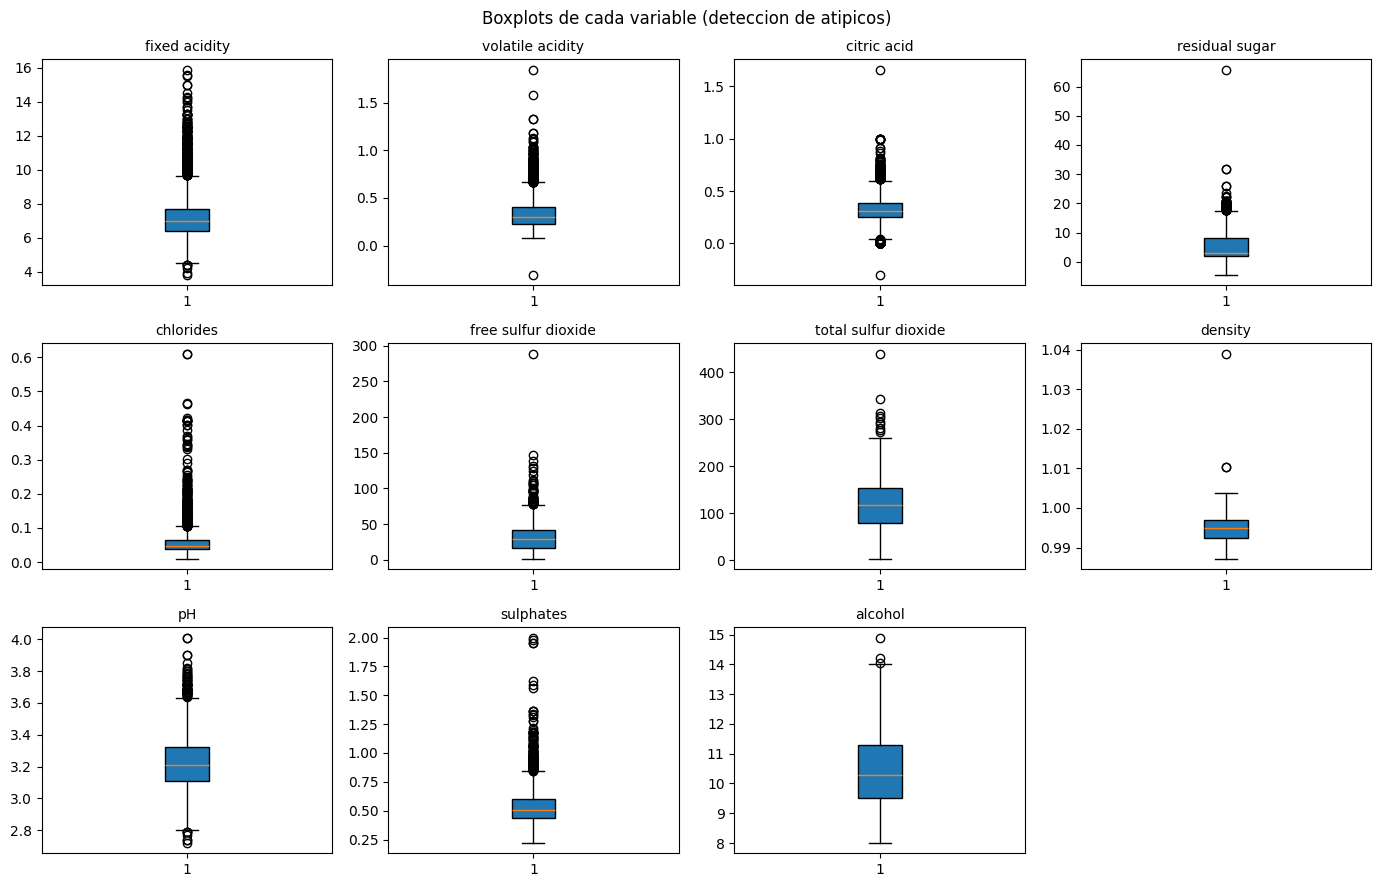

In [ ]:
# Graficamos boxplots de cada variable para ver los atipicos
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()
for i, columna in enumerate(columnas_numericas):
    axes[i].boxplot(df_imputado[columna], patch_artist=True)
    axes[i].set_title(columna, fontsize=10)
axes[-1].axis('off')
plt.suptitle('Boxplots de cada variable (deteccion de atipicos)')
plt.tight_layout()
plt.show()

**¿Por qué graficamos con un boxplot y no con otro tipo de gráfico?** Porque el boxplot dibuja exactamente la regla del IQR que acabamos de calcular: la caja va de $Q_1$ a $Q_3$ (el 50% central de los datos), la línea de en medio es la mediana, y los "bigotes" llegan justo hasta los límites que calculamos ($Q_1 - 1.5\times IQR$ y $Q_3 + 1.5\times IQR$). Los puntos sueltos que aparecen fuera de los bigotes son ni más ni menos que los atípicos que detectamos en el código — es decir, no es una gráfica "cualquiera", es el dibujo literal de la fórmula que usamos. Un histograma no marca explícitamente cuáles puntos son atípicos (tendrías que adivinarlo a ojo), y una gráfica de línea o de dispersión no tiene mucho sentido aquí porque no estamos comparando dos variables ni hay un orden natural entre los vinos. Además, el boxplot es compacto (resume cada variable en solo 5 números), lo que nos permitió poner las 11 variables en una sola cuadrícula y comparar de un vistazo cuáles tienen más o menos atípicos.

**Interpretación:** Sí existen atípicos en casi todas las variables, en proporciones bajas-moderadas (desde 0.05% en `alcohol`/`density` hasta 7.7% en `citric acid`). **Decidimos no eliminarlos**: muchas variables químicas del vino tienen naturalmente colas pesadas (por ejemplo, un vino de postre con azúcar residual mucho más alto que el resto es un vino real, no un error de captura). Eliminarlos nos haría perder información valiosa.

**Conclusión del inciso 2:** Se imputaron las 11 variables fisicoquímicas mediante el método multivariado MICE. Los valores atípicos se conservaron porque pueden representar vinos reales con características extremas. Las variables `quality` y `type` no se imputaron, por lo que en sus análisis se utilizarán únicamente los datos disponibles y se reportará explícitamente la cantidad de valores ausentes.

---
## Inciso 3: Estadística descriptiva por variable

**Objetivo:** Describir dónde se concentra cada variable (tendencia central) y qué tan dispersos están sus valores (dispersión), ya con los datos tratados.

Después del tratamiento anterior, las 11 variables fisicoquímicas se encuentran completas gracias a la imputación multivariada con MICE. Los valores atípicos se conservaron porque pueden corresponder a vinos reales con características poco comunes.

Las variables quality y type se analizarán con sus valores disponibles. No se imputan porque quality representa el resultado sensorial que posteriormente se desea estudiar y type es una variable categórica. Imputarlas podría modificar artificialmente su distribución.

#### Paso 1: Verificar el conjunto de datos posterior al tratamiento

In [ ]:
# Verificamos el tamaño del DataFrame después del tratamiento
print("Dimensiones del conjunto de datos:", df_imputado.shape)
# Revisamos nuevamente los valores ausentes
print("\nValores ausentes después del tratamiento:")
print(df_imputado.isna().sum())

Dimensiones del conjunto de datos: (6497, 13)

Valores ausentes después del tratamiento:
fixed acidity             0
volatile acidity          0
citric acid               0
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                 591
type                    800
dtype: int64


In [ ]:
# Valores mínimos de las variables imputadas
minimos_imputados = df_imputado[columnas_numericas].min()
print("Valores mínimos después de la imputación:")
print(minimos_imputados)

Valores mínimos después de la imputación:
fixed acidity           3.800000
volatile acidity       -0.308356
citric acid            -0.302534
residual sugar         -4.549305
chlorides               0.009000
free sulfur dioxide     1.000000
total sulfur dioxide    2.430663
density                 0.987110
pH                      2.720000
sulphates               0.220000
alcohol                 8.000000
dtype: float64


**Tipo de variables:**

En este conjunto de datos se identifican los siguientes tipos de variables:

* **Variables numéricas continuas**: `fixed acidity`, `volatile` `acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates` y `alcohol`

* **Variable numérica discreta ordinal**: `quality`

* **Variable categórica nominal**: `type`

Aunque algunas variables fisicoquímicas pueden aparecer registradas con valores enteros, se consideran continuas porque representan mediciones de concentraciones o propiedades físicas.

La variable `quality` es discreta porque únicamente puede tomar ciertos puntajes y es ordinal porque sus categorías tienen un orden natural. Por otro lado, `type` es categórica nominal porque identifica si el vino es tinto o blanco sin establecer un orden entre ambas categorías.


#### Paso 2: Calcular las estadísticas descriptivas

Para las variables numéricas se calcularán las siguientes medidas descriptivas:

* **Número de datos válidos**: cantidad de observaciones disponibles utilizadas para calcular las estadísticas.

* **Valores ausentes**: cantidad de registros que no contienen información en la variable.

* **Mínimo**: valor más pequeño observado en la variable.

* **Máximo**: valor más grande observado en la variable.

* **Media**: promedio aritmético de todos los valores disponibles.

* **Mediana**: valor que divide los datos ordenados en dos partes iguales; el 50% de las observaciones queda por debajo y el otro 50% por encima.

* **Moda**: valor que aparece con mayor frecuencia en el conjunto de datos.

* **Desviación estándar**: indica cuánto se alejan, en promedio, los valores respecto a la media. Una desviación estándar elevada representa una mayor dispersión.

* **Varianza**: medida de dispersión que corresponde al cuadrado de la desviación estándar, por lo que se expresa en unidades al cuadrado.

* **Primer cuartil ($Q_1$)**: valor por debajo del cual se encuentra el 25% de las observaciones.

* **Tercer cuartil ($Q_3$)**: valor por debajo del cual se encuentra el 75% de las observaciones.

* **Rango intercuartílico o IQR**: diferencia entre el tercer y el primer cuartil:

  $$
  IQR=Q_3-Q_1
  $$

  Representa la amplitud del 50% central de los datos y es una medida poco sensible a los valores atípicos.

* **Rango**: diferencia entre el valor máximo y el mínimo:

  $$
  Rango=Máximo-Mínimo
  $$

  Permite conocer la amplitud total de los valores observados, aunque puede verse afectado por valores extremos.

* **Coeficiente de variación**: expresa la desviación estándar como porcentaje de la media:

  $$
  CV=\frac{s}{\bar{x}}\times100
  $$

  Esta medida permite comparar la dispersión relativa entre variables que se encuentran expresadas en diferentes unidades o escalas.

* **Asimetría**: indica la forma y dirección de la distribución. Un valor cercano a cero representa una distribución aproximadamente simétrica; un valor positivo señala una cola hacia los valores altos y un valor negativo indica una cola hacia los valores bajos.

Estas medidas se analizarán en conjunto, ya que ninguna estadística describe por sí sola completamente el comportamiento de una variable. La media, mediana y moda permitirán estudiar la tendencia central, mientras que la desviación estándar, el IQR, el rango y el coeficiente de variación permitirán evaluar su dispersión.


Siguiendo la lógica de la función `statcats()` del ejemplo en R visto en clase, se construye una función en Python que devuelve las principales medidas de tendencia central y dispersión.

In [ ]:
# Función para calcular estadísticas descriptivas de una variable
def estadisticas_variable(serie):

    # Eliminamos únicamente los valores ausentes para realizar los cálculos
    datos = serie.dropna()

    # Calculamos la moda
    modas = datos.mode()
    moda = modas.iloc[0] if not modas.empty else np.nan

    # Calculamos los cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1

    # Calculamos la media y la desviación estándar
    media = datos.mean()
    desviacion = datos.std()

    # Coeficiente de variación
    coeficiente_variacion = (
        desviacion / media * 100
        if media != 0
        else np.nan
    )

    # Creamos la tabla de estadísticas descriptivas
    estadisticas = pd.DataFrame({
        "Estadística": [
            "Número de datos",
            "Valores ausentes",
            "Mínimo",
            "Máximo",
            "Media",
            "Mediana",
            "Moda",
            "Desviación estándar",
            "Varianza",
            "Primer cuartil (Q1)",
            "Tercer cuartil (Q3)",
            "Rango intercuartílico (IQR)",
            "Rango",
            "Coeficiente de variación (%)",
            "Asimetría"
        ],
        "Valor": [
            datos.count(),
            serie.isna().sum(),
            datos.min(),
            datos.max(),
            media,
            datos.median(),
            moda,
            desviacion,
            datos.var(),
            q1,
            q3,
            iqr,
            datos.max() - datos.min(),
            coeficiente_variacion,
            datos.skew()
        ]
    })

    return estadisticas

Esta función proporciona información sobre:

* **Tendencia central**: media, mediana y moda.
* **Dispersión absoluta**: desviación estándar, varianza, rango e IQR.
* **Dispersión relativa**: coeficiente de variación.
* **Forma de la distribución**: asimetría.
* **Cantidad de información disponible**: número de datos válidos y valores ausentes.

#### Criterios Generales de Interpretación

Para interpretar los resultados se utilizarán las siguientes referencias.


**Comparación entre media y mediana**
* Si la media y la mediana son parecidas, la distribución puede ser aproximadamente simétrica.
* Si la media es mayor que la mediana, probablemente existe una cola hacia valores altos.
* Si la media es menor que la mediana, probablemente existe una cola hacia valores bajos.


**Asimetría**

La asimetría se interpretará de manera aproximada de la siguiente forma:

| Valor absoluto de la asimetría | Interpretación                         |
| :----------------------------: | -------------------------------------- |
|          Menor que 0.5         | Distribución aproximadamente simétrica |
|          Entre 0.5 y 1         | Asimetría moderada                     |
|           Mayor que 1          | Asimetría marcada                      |

Un valor positivo indica una cola hacia la derecha, es decir, hacia valores altos. Un valor negativo indica una cola hacia la izquierda.


**Coeficiente de variación**

El coeficiente de variación permite comparar la dispersión de variables que se encuentran en escalas diferentes:

| Coeficiente de variación | Dispersión relativa |
| :----------------------: | :-----------------: |
|      Menor que 15 %      |         Baja        |
|     Entre 15 % y 30 %    |       Moderada      |
|      Mayor que 30 %      |         Alta        |

Este criterio solamente se utilizará como referencia y deberá complementarse con el análisis de la distribución, el boxplot y el contexto de cada variable.


####Variables Continuas:
Las variables fisicoquímicas serán analizadas mediante:
1. Una tabla de estadísticas descriptivas.
2. Un boxplot para observar la mediana, dispersión y valores atípicos.

In [ ]:
# Variables fisicoquímicas continuas
columnas_continuas = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

In [ ]:
def graficar_variable_continua(df, columna):

    # Seleccionamos únicamente los valores disponibles
    datos = df[columna].dropna()

    # Creamos una figura con histograma y boxplot
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 4)
    )

    # Histograma con curva de densidad
    sns.histplot(
        datos,
        bins=30,
        kde=True,
        ax=axes[0]
    )

    # Agregamos la media
    axes[0].axvline(
        datos.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Media: {datos.mean():.3f}"
    )

    # Agregamos la mediana
    axes[0].axvline(
        datos.median(),
        linestyle=":",
        linewidth=2,
        label=f"Mediana: {datos.median():.3f}"
    )

    axes[0].set_title(f"Distribución de {columna}")
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    # Boxplot con Seaborn
    sns.boxplot(
        y=datos,
        ax=axes[1]
    )

    axes[1].set_title(f"Boxplot de {columna}")
    axes[1].set_xlabel("")
    axes[1].set_ylabel(columna)

    # Ajustamos la distribución de las gráficas
    plt.tight_layout()
    plt.show()

Las líneas verticales del histograma permiten comparar visualmente la media y la mediana. Cuando ambas líneas están muy separadas, existe evidencia de que la distribución puede estar sesgada o influida por valores extremos.

#### Análisis individual de las variables

##### Acidez fija — `fixed acidity`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     3.8000
3                         Máximo    15.9000
4                          Media     7.2161
5                        Mediana     7.0000
6                           Moda     6.8000
7            Desviación estándar     1.2719
8                       Varianza     1.6178
9            Primer cuartil (Q1)     6.4000
10           Tercer cuartil (Q3)     7.7000
11   Rango intercuartílico (IQR)     1.3000
12                         Rango    12.1000
13  Coeficiente de variación (%)    17.6264
14                     Asimetría     1.6610


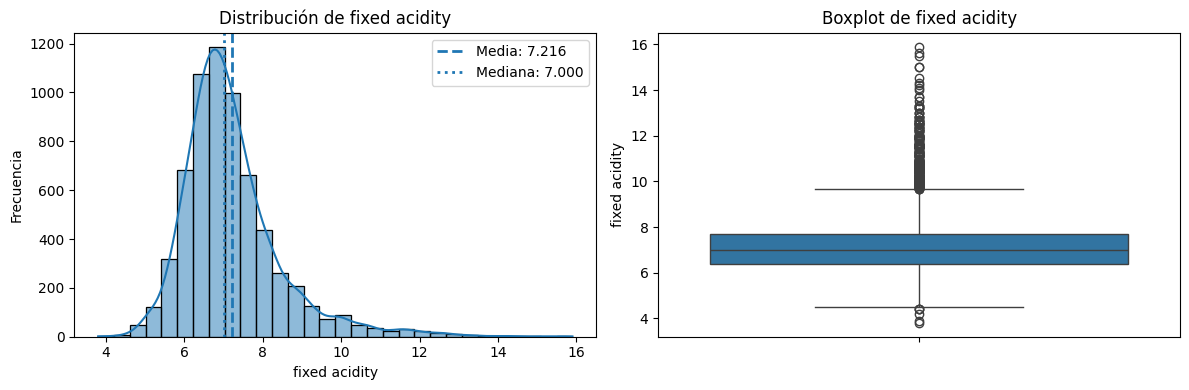

In [ ]:
print(
    estadisticas_variable(
        df_imputado["fixed acidity"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "fixed acidity"
)

**Observaciones:** La acidez fija presenta una media de 7.22, una mediana de 7.00 y una moda de 6.80 g/dm³. La media ligeramente superior a la mediana y la asimetría positiva de 1.66 indican una distribución inclinada hacia valores altos. Respecto a la dispersión, el coeficiente de variación de 17.63% muestra una variabilidad moderada y el 50% central de los datos se encuentra entre 6.4 y 7.7 g/dm³. Debido a la asimetría y a los valores atípicos superiores, la mediana y el IQR son las medidas más representativas.

##### Acidez volátil — `volatile acidity` **

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo    -0.3084
3                         Máximo     1.8473
4                          Media     0.3403
5                        Mediana     0.3000
6                           Moda     0.2800
7            Desviación estándar     0.1586
8                       Varianza     0.0252
9            Primer cuartil (Q1)     0.2300
10           Tercer cuartil (Q3)     0.4050
11   Rango intercuartílico (IQR)     0.1750
12                         Rango     2.1557
13  Coeficiente de variación (%)    46.6050
14                     Asimetría     1.5414


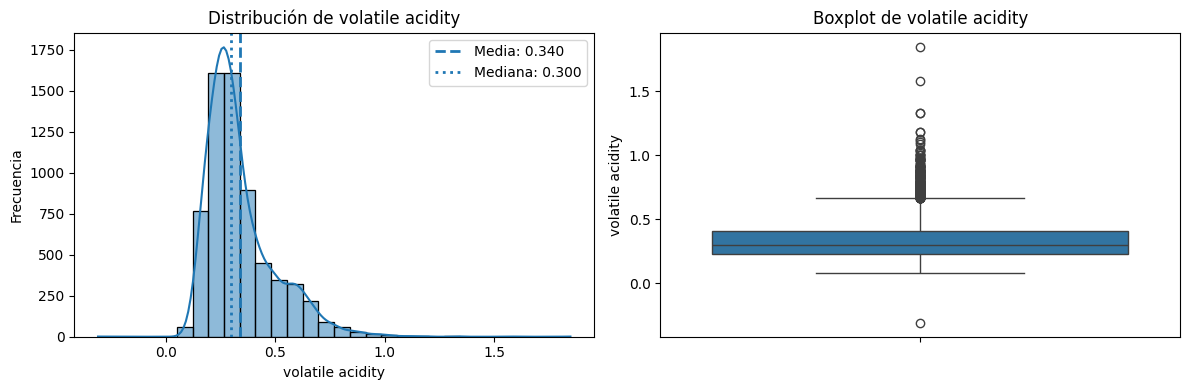

In [ ]:
print(
    estadisticas_variable(
        df_imputado["volatile acidity"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "volatile acidity"
)

**Observaciones:** La acidez volátil presenta una media de 0.3403, una mediana de 0.3000 y una moda de 0.2800 g/dm³. La media superior a la mediana y la asimetría positiva de 1.54 indican una distribución inclinada hacia valores altos. El coeficiente de variación de 46.61% refleja una dispersión relativa alta, mientras que el 50% central se encuentra entre 0.230 y 0.405 g/dm³. Debido a la asimetría y a los numerosos valores atípicos superiores, la mediana y el IQR son las medidas más representativas.

##### Ácido cítrico — `citric acid`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo    -0.3025
3                         Máximo     1.6600
4                          Media     0.3185
5                        Mediana     0.3100
6                           Moda     0.3000
7            Desviación estándar     0.1413
8                       Varianza     0.0200
9            Primer cuartil (Q1)     0.2500
10           Tercer cuartil (Q3)     0.3900
11   Rango intercuartílico (IQR)     0.1400
12                         Rango     1.9625
13  Coeficiente de variación (%)    44.3460
14                     Asimetría     0.4462


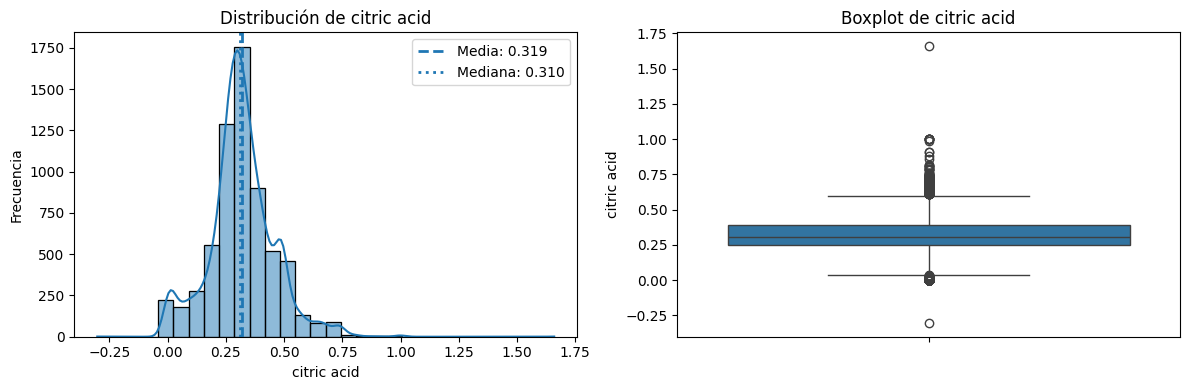

In [ ]:
print(
    estadisticas_variable(
        df_imputado["citric acid"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "citric acid"
)

**Observaciones:** El ácido cítrico presenta una media de 0.3185, una mediana de 0.3100 y una moda de 0.3000 g/dm³, por lo que las medidas de tendencia central son muy cercanas. La asimetría positiva de 0.45 indica una distribución ligeramente inclinada hacia valores altos. El coeficiente de variación de 44.35% refleja una dispersión relativa alta, mientras que el 50% central se encuentra entre 0.25 y 0.39 g/dm³. Aunque existen valores atípicos, la cercanía entre media y mediana permite utilizar la media y la desviación estándar como medidas representativas.

##### Azúcar residual — `residual sugar` **

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo    -4.5493
3                         Máximo    65.8000
4                          Media     5.4447
5                        Mediana     3.1000
6                           Moda     2.0000
7            Desviación estándar     4.7491
8                       Varianza    22.5535
9            Primer cuartil (Q1)     1.8000
10           Tercer cuartil (Q3)     8.1000
11   Rango intercuartílico (IQR)     6.3000
12                         Rango    70.3493
13  Coeficiente de variación (%)    87.2235
14                     Asimetría     1.4250


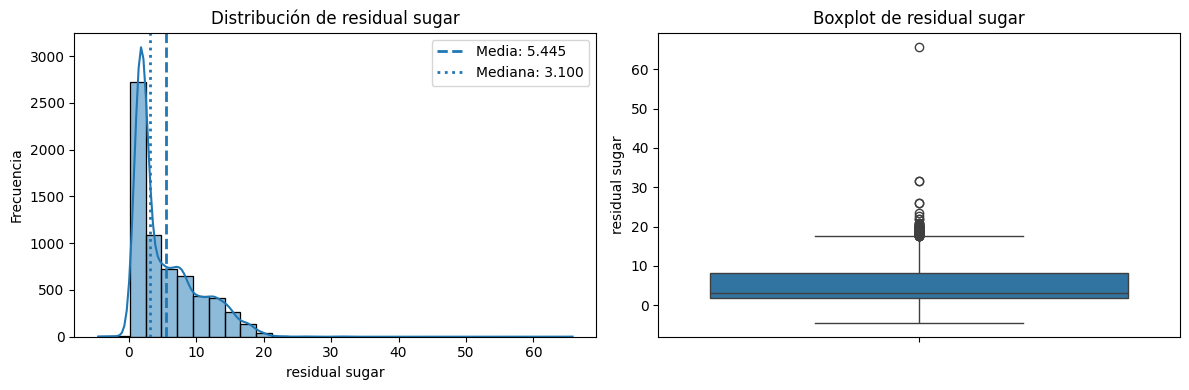

In [ ]:
print(
    estadisticas_variable(
        df_imputado["residual sugar"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "residual sugar"
)

**Observaciones:** El azúcar residual presenta una media de 5.44, una mediana de 3.10 y una moda de 2.00 g/dm³. La diferencia entre estas medidas y la asimetría positiva de 1.43 muestran una distribución inclinada hacia valores altos. El coeficiente de variación de 87.22% indica una dispersión relativa muy alta, mientras que el 50% central se encuentra entre 1.8 y 8.1 g/dm³. Debido a la fuerte asimetría y a los valores atípicos superiores, la mediana y el IQR son las medidas más representativas.

##### Cloruros — `chlorides`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     0.0090
3                         Máximo     0.6110
4                          Media     0.0560
5                        Mediana     0.0470
6                           Moda     0.0440
7            Desviación estándar     0.0350
8                       Varianza     0.0012
9            Primer cuartil (Q1)     0.0380
10           Tercer cuartil (Q3)     0.0650
11   Rango intercuartílico (IQR)     0.0270
12                         Rango     0.6020
13  Coeficiente de variación (%)    62.5222
14                     Asimetría     5.3998


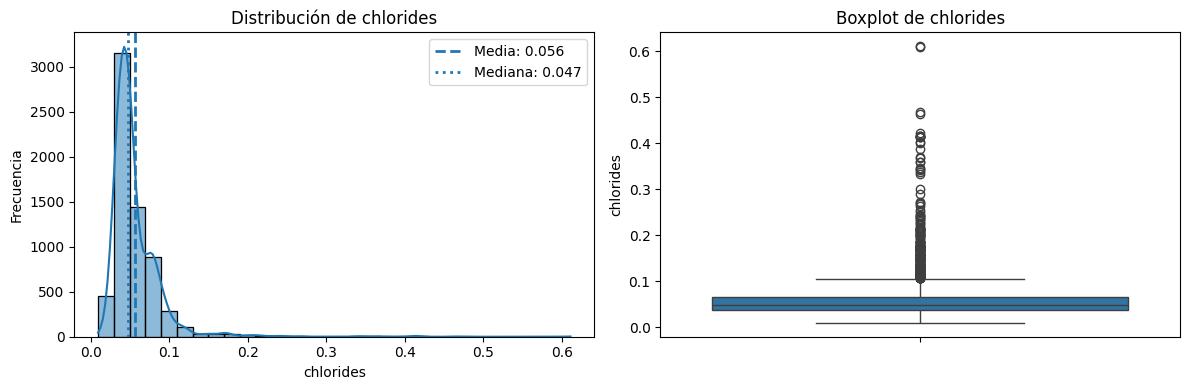

In [ ]:
print(
    estadisticas_variable(
        df_imputado["chlorides"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "chlorides"
)

**Observaciones:** Los cloruros presentan una media de 0.056, una mediana de 0.047 y una moda de 0.044 g/dm³. La media superior a la mediana y la asimetría positiva de 5.40 muestran una distribución fuertemente inclinada hacia valores altos. El coeficiente de variación de 62.52% indica una dispersión relativa alta, mientras que el 50% central se encuentra entre 0.038 y 0.065 g/dm³. Debido a la marcada asimetría y a los numerosos valores atípicos superiores, la mediana y el IQR son las medidas más representativas.

##### Dióxido de azufre libre — `free sulfur dioxide`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     1.0000
3                         Máximo   289.0000
4                          Media    30.5203
5                        Mediana    29.0000
6                           Moda    29.0000
7            Desviación estándar    17.6359
8                       Varianza   311.0236
9            Primer cuartil (Q1)    17.0000
10           Tercer cuartil (Q3)    41.0000
11   Rango intercuartílico (IQR)    24.0000
12                         Rango   288.0000
13  Coeficiente de variación (%)    57.7840
14                     Asimetría     1.2053


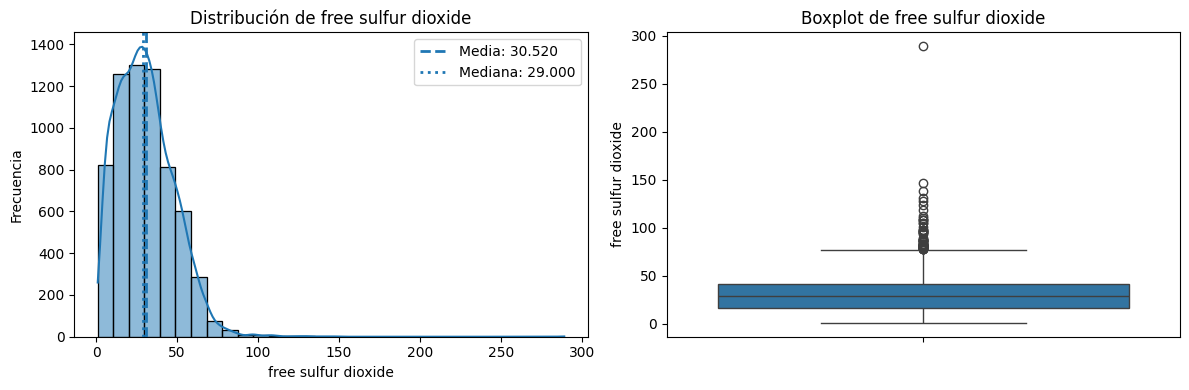

In [ ]:
print(
    estadisticas_variable(
        df_imputado["free sulfur dioxide"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "free sulfur dioxide"
)

**Observaciones:** El dióxido de azufre libre presenta una media de 30.52, una mediana y moda de 29 mg/dm³. La media ligeramente superior a la mediana y la asimetría positiva de 1.21 indican una distribución inclinada hacia valores altos. El coeficiente de variación de 57.78% refleja una dispersión relativa alta, mientras que el 50% central se encuentra entre 17 y 41 mg/dm³. Debido a la asimetría y a la presencia de valores atípicos superiores, incluida una observación extrema de 289 mg/dm³, la mediana y el IQR son las medidas más representativas.

##### Dióxido de azufre total — `total sulfur dioxide`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     2.4307
3                         Máximo   440.0000
4                          Media   115.6533
5                        Mediana   117.1673
6                           Moda   111.0000
7            Desviación estándar    54.7967
8                       Varianza  3002.6747
9            Primer cuartil (Q1)    79.0000
10           Tercer cuartil (Q3)   154.0000
11   Rango intercuartílico (IQR)    75.0000
12                         Rango   437.5693
13  Coeficiente de variación (%)    47.3801
14                     Asimetría     0.0176


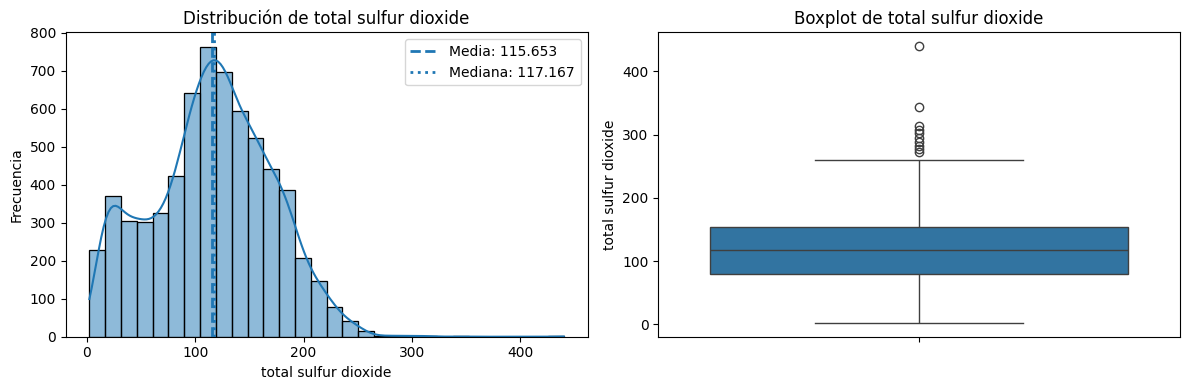

In [ ]:
print(
    estadisticas_variable(
        df_imputado["total sulfur dioxide"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "total sulfur dioxide"
)

**Observaciones:** El dióxido de azufre total presenta una media de 115.65, una mediana de 117.17 y una moda de 111 mg/dm³. La cercanía entre la media y la mediana, junto con una asimetría de 0.02, indica una distribución globalmente equilibrada. Sin embargo, el coeficiente de variación de 47.38% refleja una dispersión relativa alta y el 50% central se encuentra entre 79 y 154 mg/dm³. Aunque la media y la desviación estándar son representativas, el histograma sugiere la existencia de distintos grupos de vinos y el boxplot muestra algunos valores atípicos superiores, por lo que conviene complementar el análisis con la mediana y el IQR.

##### Densidad — `density`

                     Estadística        Valor
0                Número de datos  6497.000000
1               Valores ausentes     0.000000
2                         Mínimo     0.987110
3                         Máximo     1.038980
4                          Media     0.994697
5                        Mediana     0.994890
6                           Moda     0.997200
7            Desviación estándar     0.002999
8                       Varianza     0.000009
9            Primer cuartil (Q1)     0.992340
10           Tercer cuartil (Q3)     0.996990
11   Rango intercuartílico (IQR)     0.004650
12                         Rango     0.051870
13  Coeficiente de variación (%)     0.301466
14                     Asimetría     0.503602


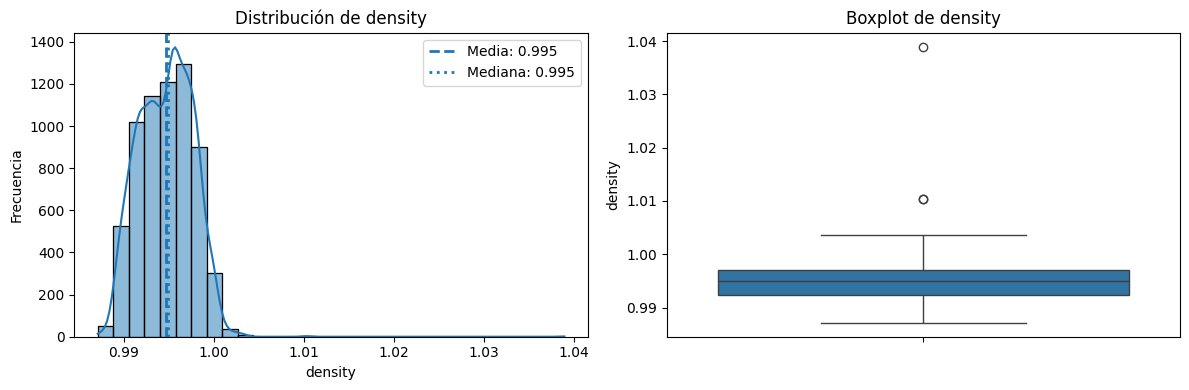

In [ ]:
print(
    estadisticas_variable(
        df_imputado["density"]
    ).round(6)
)

graficar_variable_continua(
    df_imputado,
    "density"
)

**Observaciones:** La densidad presenta una media de 0.994697, una mediana de 0.994890 y una moda de 0.997200 g/cm³, por lo que las medidas de tendencia central son muy cercanas. El coeficiente de variación de apenas 0.30% indica una dispersión relativa muy baja, y el 50% central se encuentra entre 0.992340 y 0.996990 g/cm³. Aunque la asimetría positiva de 0.50 y el boxplot muestran algunos valores atípicos superiores, la media y la desviación estándar representan adecuadamente el comportamiento general de la variable.

##### Nivel de acidez — `pH`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     2.7200
3                         Máximo     4.0100
4                          Media     3.2185
5                        Mediana     3.2100
6                           Moda     3.1600
7            Desviación estándar     0.1602
8                       Varianza     0.0257
9            Primer cuartil (Q1)     3.1100
10           Tercer cuartil (Q3)     3.3200
11   Rango intercuartílico (IQR)     0.2100
12                         Rango     1.2900
13  Coeficiente de variación (%)     4.9776
14                     Asimetría     0.3870


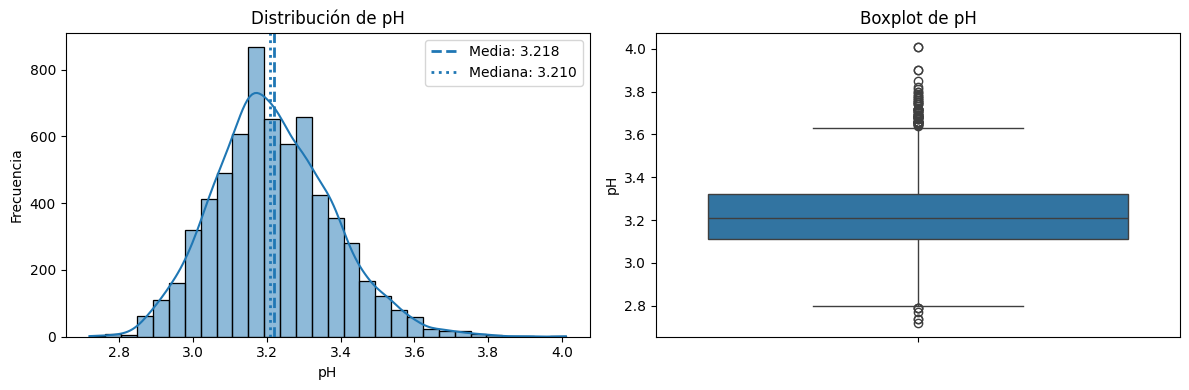

In [ ]:
print(
    estadisticas_variable(
        df_imputado["pH"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "pH"
)

**Observaciones:** El pH presenta una media de 3.2185, una mediana de 3.2100 y una moda de 3.1600, por lo que las medidas de tendencia central son muy cercanas. La asimetría positiva de 0.39 indica una distribución aproximadamente simétrica. El coeficiente de variación de 4.98% refleja una dispersión relativa baja, mientras que el 50% central se encuentra entre 3.11 y 3.32. Aunque el boxplot muestra algunos valores atípicos en ambos extremos, la media y la desviación estándar representan adecuadamente el comportamiento general de la variable.

##### Sulfatos — `sulphates`

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     0.2200
3                         Máximo     2.0000
4                          Media     0.5313
5                        Mediana     0.5100
6                           Moda     0.5000
7            Desviación estándar     0.1450
8                       Varianza     0.0210
9            Primer cuartil (Q1)     0.4400
10           Tercer cuartil (Q3)     0.6000
11   Rango intercuartílico (IQR)     0.1600
12                         Rango     1.7800
13  Coeficiente de variación (%)    27.2814
14                     Asimetría     1.8315


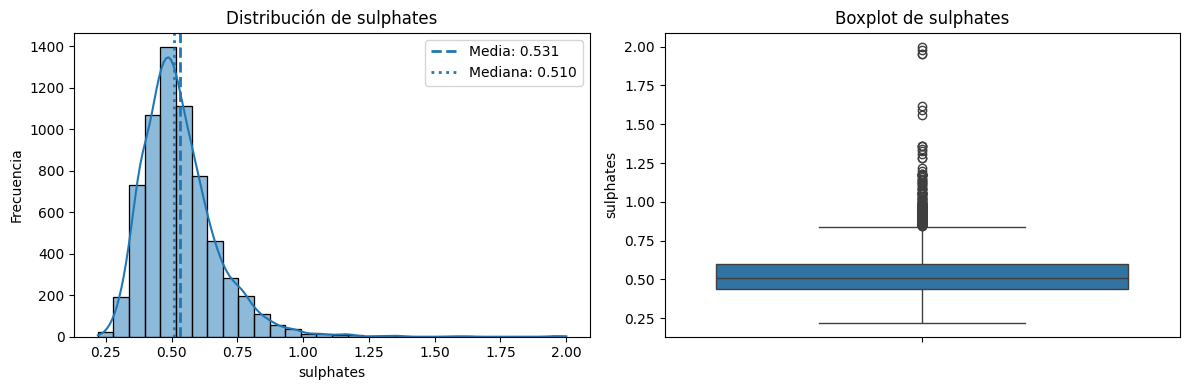

In [ ]:
print(
    estadisticas_variable(
        df_imputado["sulphates"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "sulphates"
)

**Observaciones:** Los sulfatos presentan una media de 0.5313, una mediana de 0.5100 y una moda de 0.5000 g/dm³. La media superior a la mediana y la asimetría positiva de 1.83 indican una distribución inclinada hacia valores altos. El coeficiente de variación de 27.28% refleja una dispersión relativa moderada, mientras que el 50% central se encuentra entre 0.44 y 0.60 g/dm³. Debido a la asimetría marcada y a los numerosos valores atípicos superiores, la mediana y el IQR son las medidas más representativas.

##### Contenido de alcohol — `alcohol` **

                     Estadística      Valor
0                Número de datos  6497.0000
1               Valores ausentes     0.0000
2                         Mínimo     8.0000
3                         Máximo    14.9000
4                          Media    10.4950
5                        Mediana    10.3000
6                           Moda     9.5000
7            Desviación estándar     1.1889
8                       Varianza     1.4134
9            Primer cuartil (Q1)     9.5000
10           Tercer cuartil (Q3)    11.3000
11   Rango intercuartílico (IQR)     1.8000
12                         Rango     6.9000
13  Coeficiente de variación (%)    11.3278
14                     Asimetría     0.5583


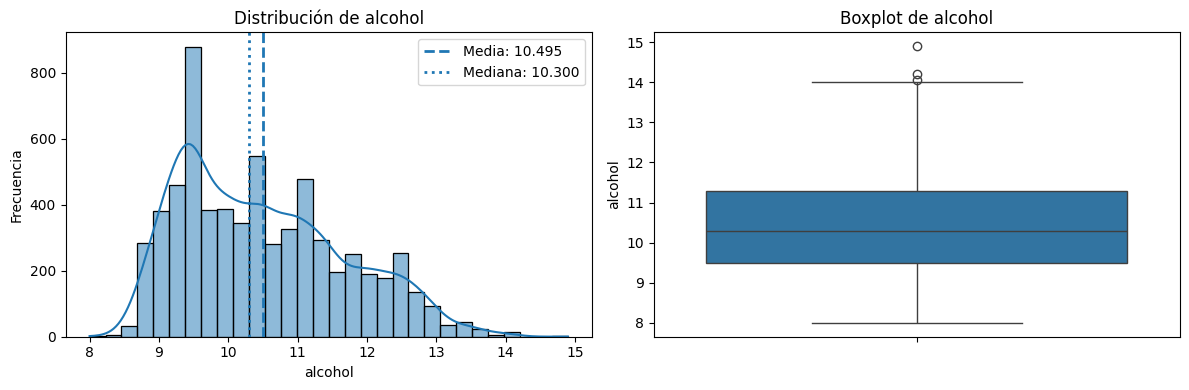

In [ ]:
print(
    estadisticas_variable(
        df_imputado["alcohol"]
    ).round(4)
)

graficar_variable_continua(
    df_imputado,
    "alcohol"
)

**Observaciones:** El contenido de alcohol presenta una media de 10.50%, una mediana de 10.30% y una moda de 9.50%. La media ligeramente superior a la mediana y la asimetría positiva de 0.56 indican una inclinación moderada hacia valores altos. El coeficiente de variación de 11.33% refleja una dispersión relativa baja, mientras que el 50% central se encuentra entre 9.5% y 11.3%. Aunque existen algunos valores atípicos superiores, la cercanía entre la media y la mediana permite utilizar la media y la desviación estándar como medidas representativas.

##### Análisis de la variable discreta ordinal `quality` **

La variable `quality` representa el puntaje asignado por los catadores. Debido a que toma valores discretos, su distribución se representa mejor mediante una gráfica de barras y una tabla de frecuencias.

In [ ]:
#Estadísticas descriptivas

print( estadisticas_variable( df_imputado["quality"] ).round(4) )

                     Estadística      Valor
0                Número de datos  5906.0000
1               Valores ausentes   591.0000
2                         Mínimo     3.0000
3                         Máximo     9.0000
4                          Media     5.8190
5                        Mediana     6.0000
6                           Moda     6.0000
7            Desviación estándar     0.8729
8                       Varianza     0.7620
9            Primer cuartil (Q1)     5.0000
10           Tercer cuartil (Q3)     6.0000
11   Rango intercuartílico (IQR)     1.0000
12                         Rango     6.0000
13  Coeficiente de variación (%)    15.0011
14                     Asimetría     0.1863


In [ ]:
#Tabla de frecuencias
# Eliminamos temporalmente los valores ausentes
calidad_valida = df_imputado["quality"].dropna()

# Frecuencia absoluta
frecuencia_calidad = (
    calidad_valida
    .value_counts()
    .sort_index()
)

# Frecuencia relativa
porcentaje_calidad = (
    frecuencia_calidad
    / frecuencia_calidad.sum()
    * 100
)

# Tabla de frecuencias
tabla_calidad = pd.DataFrame({
    "Frecuencia": frecuencia_calidad,
    "Porcentaje (%)": porcentaje_calidad
})

tabla_calidad.round(2)


,Frecuencia,Porcentaje (%)
quality,,
3.0,26,0.44
4.0,200,3.39
5.0,1938,32.81
6.0,2578,43.65
7.0,985,16.68
8.0,175,2.96
9.0,4,0.07


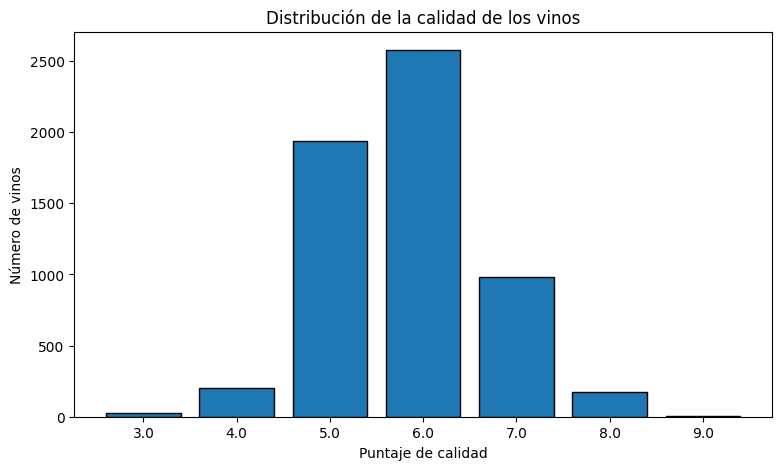

In [ ]:
#Gráfica de barras
plt.figure(figsize=(9, 5))

plt.bar(
    frecuencia_calidad.index.astype(str),
    frecuencia_calidad.values,
    edgecolor="black"
)

plt.title("Distribución de la calidad de los vinos")
plt.xlabel("Puntaje de calidad")
plt.ylabel("Número de vinos")

plt.show()

Para esta variable, la mediana y la moda son más importantes que la media, debido a que representa una escala ordinal. También se debe identificar el puntaje que concentra la mayor cantidad de vinos y revisar si las calificaciones se encuentran agrupadas alrededor de los valores centrales.

**Observaciones:** La calidad presenta una mediana y moda de 6, mientras que la media es de 5.82 puntos. La distribución se concentra principalmente en las calificaciones 5 y 6, que reúnen el 76.46% de los vinos evaluados. El IQR de 1 punto muestra una dispersión baja alrededor de los valores centrales y la asimetría de 0.19 indica una distribución aproximadamente equilibrada. Debido a que quality es una variable ordinal, la mediana, la moda y las frecuencias son más representativas que la media y el coeficiente de variación. Además, existen 591 valores ausentes, por lo que el análisis se realizó con 5,906 vinos evaluados.

##### Análisis de la variable categórica `type` **

La variable type identifica si cada observación corresponde a un vino tinto o blanco. Al ser categórica, no deben calcularse medidas como la media o la desviación estándar.
Su descripción se realiza mediante frecuencias absolutas, porcentajes y moda.

In [ ]:
#Tabla de frecuencias

# Incluimos los valores ausentes como una categoría informativa
tipo_analisis = df_imputado["type"].fillna("Sin dato")

# Frecuencia absoluta
frecuencia_tipo = tipo_analisis.value_counts()

# Porcentaje
porcentaje_tipo = (
    frecuencia_tipo
    / frecuencia_tipo.sum()
    * 100
)

# Tabla descriptiva
tabla_tipo = pd.DataFrame({
    "Frecuencia": frecuencia_tipo,
    "Porcentaje (%)": porcentaje_tipo
})

tabla_tipo.round(2)

,Frecuencia,Porcentaje (%)
type,,
white,4364,67.17
red,1333,20.52
Sin dato,800,12.31


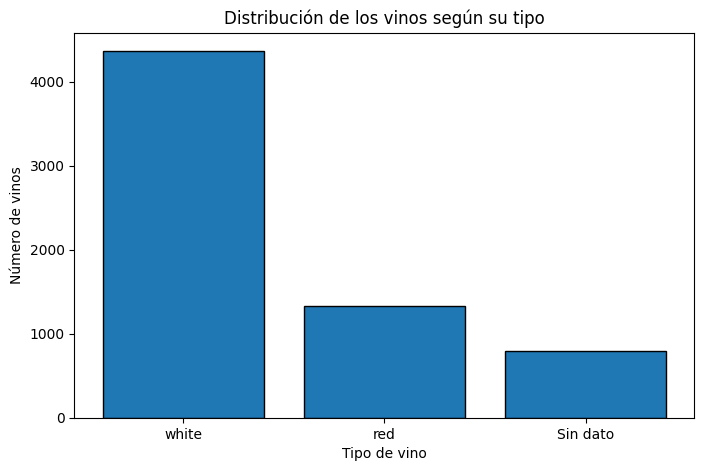

In [ ]:
#Gráfica de barras
plt.figure(figsize=(8, 5))

plt.bar(
    frecuencia_tipo.index,
    frecuencia_tipo.values,
    edgecolor="black"
)

plt.title("Distribución de los vinos según su tipo")
plt.xlabel("Tipo de vino")
plt.ylabel("Número de vinos")

plt.show()

**Observaciones:** La categoría predominante o moda es white, con 4,364 vinos (67.17%), seguida de red, con 1,333 (20.52%). Además, existen 800 registros sin información (12.31%). La diferencia entre las frecuencias muestra que el conjunto está desbalanceado y tiene una mayor representación de vinos blancos, por lo que los resultados generales pueden estar más influenciados por sus características. Al ser una variable categórica nominal, se describe mediante la moda, las frecuencias y los porcentajes, no mediante medidas de dispersión.

#### Tabla general de estadísticas descriptivas
Además del análisis individual, se puede construir una tabla resumida que permita comparar las variables numéricas.

In [ ]:
# Incluimos las variables continuas y quality
columnas_numericas_descriptivas = (
    columnas_continuas + ["quality"]
)

# Creamos la tabla general de estadísticas descriptivas
tabla_general = (
    df_imputado[columnas_numericas_descriptivas]
    .describe()
    .T
)

# Agregamos la mediana
tabla_general["mediana"] = (
    df_imputado[columnas_numericas_descriptivas]
    .median()
)

# Agregamos la moda
tabla_general["moda"] = [
    (
        df_imputado[columna]
        .mode()
        .iloc[0]
        if not df_imputado[columna].mode().empty
        else np.nan
    )
    for columna in columnas_numericas_descriptivas
]

# Agregamos la varianza
tabla_general["varianza"] = (
    df_imputado[columnas_numericas_descriptivas]
    .var()
)

# Calculamos el rango intercuartílico
tabla_general["IQR"] = (
    tabla_general["75%"]
    - tabla_general["25%"]
)

# Calculamos el rango
tabla_general["rango"] = (
    tabla_general["max"]
    - tabla_general["min"]
)

# Calculamos el coeficiente de variación
tabla_general["CV (%)"] = (
    tabla_general["std"]
    / tabla_general["mean"]
    * 100
)

# Calculamos la asimetría
tabla_general["asimetría"] = (
    df_imputado[columnas_numericas_descriptivas]
    .skew()
)

# Ordenamos las columnas
tabla_general = tabla_general[
    [
        "count",
        "mean",
        "mediana",
        "moda",
        "std",
        "varianza",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "IQR",
        "rango",
        "CV (%)",
        "asimetría"
    ]
]

# Mostramos la tabla
tabla_general.round(4)

,count,mean,mediana,moda,std,varianza,min,25%,50%,75%,max,IQR,rango,CV (%),asimetría
fixed acidity,6497.0,7.2161,7.0000,6.8000,1.2719,1.6178,3.8000,6.4000,7.0000,7.700,15.9000,1.3000,12.1000,17.6264,1.6610
volatile acidity,6497.0,0.3403,0.3000,0.2800,0.1586,0.0252,-0.3084,0.2300,0.3000,0.405,1.8473,0.1750,2.1557,46.6050,1.5414
citric acid,6497.0,0.3185,0.3100,0.3000,0.1413,0.0200,-0.3025,0.2500,0.3100,0.390,1.6600,0.1400,1.9625,44.3460,0.4462
residual sugar,6497.0,5.4447,3.1000,2.0000,4.7491,22.5535,-4.5493,1.8000,3.1000,8.100,65.8000,6.3000,70.3493,87.2235,1.4250
chlorides,6497.0,0.0560,0.0470,0.0440,0.0350,0.0012,0.0090,0.0380,0.0470,0.065,0.6110,0.0270,0.6020,62.5222,5.3998
free sulfur dioxide,6497.0,30.5203,29.0000,29.0000,17.6359,311.0236,1.0000,17.0000,29.0000,41.000,289.0000,24.0000,288.0000,57.7840,1.2053
total sulfur dioxide,6497.0,115.6533,117.1673,111.0000,54.7967,3002.6747,2.4307,79.0000,117.1673,154.000,440.0000,75.0000,437.5693,47.3801,0.0176
density,6497.0,0.9947,0.9949,0.9972,0.0030,0.0000,0.9871,0.9923,0.9949,0.997,1.0390,0.0047,0.0519,0.3015,0.5036
pH,6497.0,3.2185,3.2100,3.1600,0.1602,0.0257,2.7200,3.1100,3.2100,3.320,4.0100,0.2100,1.2900,4.9776,0.3870
sulphates,6497.0,0.5313,0.5100,0.5000,0.1450,0.0210,0.2200,0.4400,0.5100,0.600,2.0000,0.1600,1.7800,27.2814,1.8315


---
## Inciso 4: Comparativa tinto vs. blanco

**Objetivo:** Comparar variables entre tipos de vino. Ejemplo guía del profesor: ¿los tintos tienen más acidez fija que los blancos?

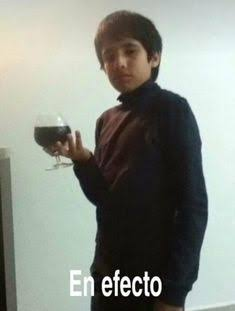

###  Preparación de datos

In [ ]:
# Creamos una copia para realizar las comparaciones (únicamente los registros cuyo tipo de vino es conocido)
df_comparacion = df_imputado[
    df_imputado["type"].isin(["red", "white"])
].copy()

# Traducimos las categorías
df_comparacion["Tipo de vino"] = (
    df_comparacion["type"]
    .map({
        "red": "Tinto",
        "white": "Blanco"
    })
)

orden_tipos = ["Tinto", "Blanco"]

# Corregimos para este análisis los valores negativos imposibles
variables_no_negativas = [
    "fixed acidity",
    "volatile acidity",
    "residual sugar",
    "total sulfur dioxide",
    "density",
    "alcohol"
]

for columna in variables_no_negativas:
    df_comparacion.loc[
        df_comparacion[columna] < 0,
        columna
    ] = np.nan

print(df_comparacion["Tipo de vino"].value_counts())

Tipo de vino
Blanco    4364
Tinto     1333
Name: count, dtype: int64


In [ ]:
#Función para comparar una variable entre tipos de vino (tabla descriptiva, gráfica de densidad y un boxplot.)
def comparar_variable_por_tipo(
    df,
    variable,
    titulo,
    etiqueta
):

    # Tabla descriptiva
    resumen = (
        df
        .groupby(
            "Tipo de vino",
            observed=True
        )[variable]
        .agg(
            N="count",
            Media="mean",
            Mediana="median",
            Desviación_estándar="std",
            Q1=lambda x: x.quantile(0.25),
            Q3=lambda x: x.quantile(0.75),
            Mínimo="min",
            Máximo="max"
        )
    )

    resumen["IQR"] = resumen["Q3"] - resumen["Q1"]

    display(resumen.round(4))

    # Datos disponibles
    datos = df[
        ["Tipo de vino", variable]
    ].dropna()

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13, 4.5)
    )

    # Distribución
    sns.kdeplot(
        data=datos,
        x=variable,
        hue="Tipo de vino",
        hue_order=orden_tipos,
        fill=True,
        common_norm=False,
        alpha=0.30,
        cut=0,
        ax=axes[0]
    )

    axes[0].set_title(f"Distribución de {titulo}")
    axes[0].set_xlabel(etiqueta)
    axes[0].set_ylabel("Densidad")

    # Boxplot
    sns.boxplot(
        data=datos,
        x="Tipo de vino",
        y=variable,
        order=orden_tipos,
        ax=axes[1]
    )

    axes[1].set_title(f"{titulo} según el tipo de vino")
    axes[1].set_xlabel("Tipo de vino")
    axes[1].set_ylabel(etiqueta)

    plt.tight_layout()
    plt.show()

In [ ]:
#Función para comparar la relación entre dos variables (correlación de Spearman, diagrama de dispersión)

def comparar_relacion_por_tipo(
    df,
    variable_x,
    variable_y,
    titulo,
    etiqueta_x,
    etiqueta_y
):

    datos = (
        df[
            [
                "Tipo de vino",
                variable_x,
                variable_y
            ]
        ]
        .dropna()
        .copy()
    )

    resultados = []

    for tipo in orden_tipos:

        grupo = datos[
            datos["Tipo de vino"] == tipo
        ]

        resultados.append({
            "Tipo de vino": tipo,
            "N": len(grupo),
            f"Media de {variable_x}": grupo[variable_x].mean(),
            f"Mediana de {variable_x}": grupo[variable_x].median(),
            f"Media de {variable_y}": grupo[variable_y].mean(),
            f"Mediana de {variable_y}": grupo[variable_y].median(),
            "Correlación de Spearman": (
                grupo[variable_x]
                .corr(
                    grupo[variable_y],
                    method="spearman"
                )
            )
        })

    resumen = pd.DataFrame(resultados)
    display(resumen.round(4))

    grafica = sns.lmplot(
        data=datos,
        x=variable_x,
        y=variable_y,
        hue="Tipo de vino",
        hue_order=orden_tipos,
        ci=None,
        scatter_kws={
            "alpha": 0.25,
            "s": 25
        },
        line_kws={
            "linewidth": 2
        },
        height=5,
        aspect=1.4
    )

    grafica.set_axis_labels(
        etiqueta_x,
        etiqueta_y
    )

    grafica.fig.suptitle(
        titulo,
        y=1.03
    )

    plt.show()

### Acidez Fija Según el tipo de vino

Decidimos comparar la acidez fija entre vinos tintos y blancos porque esta variable representa la concentración de ácidos no volátiles que contribuyen a la estructura, frescura y equilibrio del vino.

El objetivo es comprobar si uno de los tipos presenta valores centrales mayores y si la diferencia se observa en toda la distribución o solamente en algunos valores extremos.

,N,Media,Mediana,Desviación_estándar,Q1,Q3,Mínimo,Máximo,IQR
Tipo de vino,,,,,,,,,
Blanco,4364,6.8451,6.8,0.8314,6.3000,7.3,3.8,14.2,1.0000
Tinto,1333,8.3358,8.0,1.6637,7.1878,9.2,4.6,15.9,2.0122


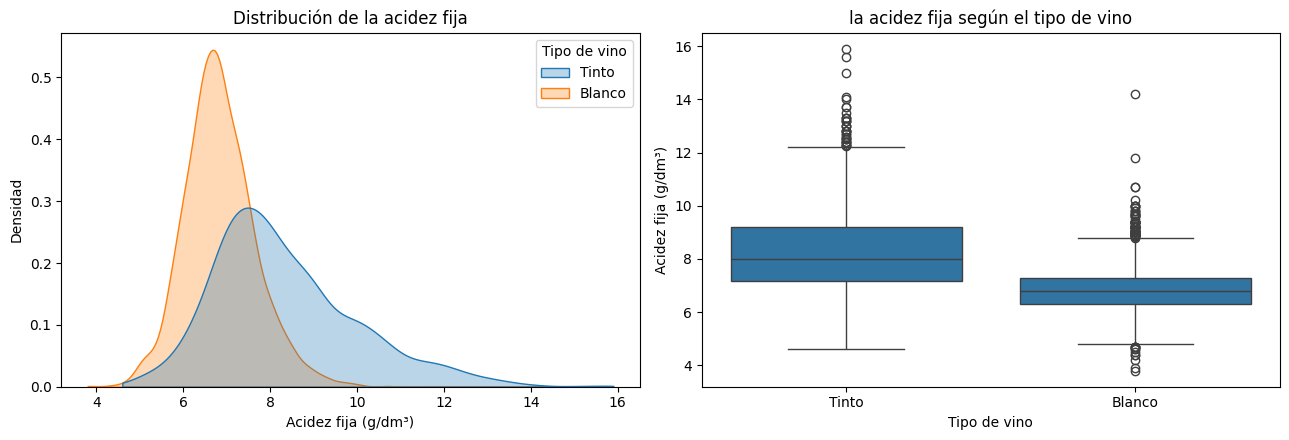

In [ ]:
comparar_variable_por_tipo(
    df_comparacion,
    "fixed acidity",
    "la acidez fija",
    "Acidez fija (g/dm³)"
)

Los vinos tintos presentan una acidez fija mayor, con una media de 8.34 y una mediana de 8.00 g/dm³, frente a 6.85 y 6.80 g/dm³ en los blancos. También muestran mayor dispersión, con una desviación estándar de 1.66 y un IQR de 2.01, mientras que en los blancos son de 0.83 y 1.00, respectivamente. Aunque existe cierto traslape, **la distribución de los tintos está desplazada hacia valores más altos y es más amplia.**

Esto significa que, en este conjunto de datos, los vinos tintos suelen contener una mayor concentración de ácidos fijos y presentan una composición más variable. Esta mayor acidez puede contribuir a su estructura, equilibrio y sensación de frescura; sin embargo, no implica por sí sola que tengan un sabor más ácido, ya que también debe considerarse el pH.

### Dioxido de azufre total según el tipo de vino

Decidimos comparar el dióxido de azufre total porque se utiliza para proteger el vino frente a la oxidación y el deterioro microbiológico. Las necesidades de conservación pueden cambiar entre vinos tintos y blancos debido a diferencias en su composición, elaboración y estabilidad.

Nos interesa identificar si alguno de los tipos presenta concentraciones mayores y si las distribuciones se encuentran claramente separadas.

,N,Media,Mediana,Desviación_estándar,Q1,Q3,Mínimo,Máximo,IQR
Tipo de vino,,,,,,,,,
Blanco,4364,137.2526,133.0000,41.6865,107.0,166.0,9.0000,440.0,59.0
Tinto,1333,49.6303,43.0618,32.5254,24.0,66.0,2.4307,289.0,42.0


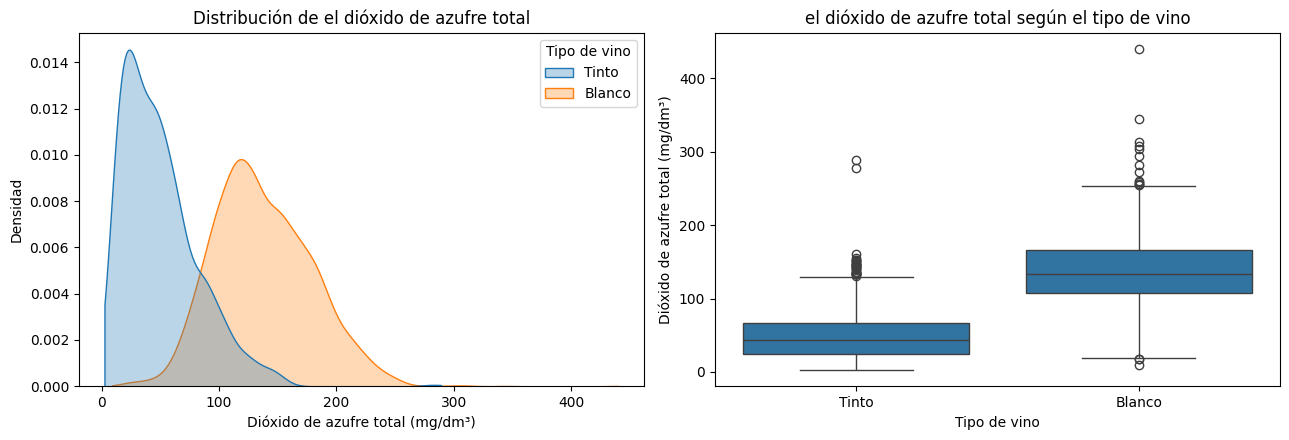

In [ ]:
comparar_variable_por_tipo(
    df_comparacion,
    "total sulfur dioxide",
    "el dióxido de azufre total",
    "Dióxido de azufre total (mg/dm³)"
)

Los vinos blancos presentan concentraciones considerablemente mayores de dióxido de azufre total, con una media de 137.25 y una mediana de 133 mg/dm³, frente a 49.63 y 43.06 mg/dm³ en los tintos. En términos absolutos, los blancos también presentan mayor dispersión, con una desviación estándar de 41.69 y un IQR de 59, mientras que en los tintos son de 32.53 y 42, respectivamente. Las distribuciones se encuentran claramente desplazadas, aunque existe una zona de traslape y valores atípicos superiores en ambos grupos.

Esto significa que, en este conjunto de datos, **los vinos blancos suelen recibir o conservar una mayor cantidad de dióxido de azufre**. Esto puede relacionarse con mayores necesidades de protección frente a la oxidación y el deterioro microbiológico durante su elaboración y almacenamiento. No significa que los vinos blancos sean de menor calidad, sino que sus procesos de conservación pueden requerir un manejo diferente al de los tintos.

### Alcohol y densidad según el tipo de vino



Decidimos comparar la densidad y el contenido de alcohol porque ambas variables están relacionadas con la composición física del vino. El alcohol es menos denso que el agua, por lo que, en términos generales, un mayor contenido de alcohol puede asociarse con una menor densidad.

Sin embargo, la densidad también depende del azúcar y de otras sustancias disueltas. Por ello, nos interesa comprobar si la relación inversa entre alcohol y densidad aparece en los datos y si se comporta de manera diferente en vinos tintos y blancos.

,Tipo de vino,N,Media de alcohol,Mediana de alcohol,Media de density,Mediana de density,Correlación de Spearman
0,Tinto,1333,10.4231,10.2,0.9967,0.9967,-0.4625
1,Blanco,4364,10.5172,10.4,0.9940,0.9937,-0.8222


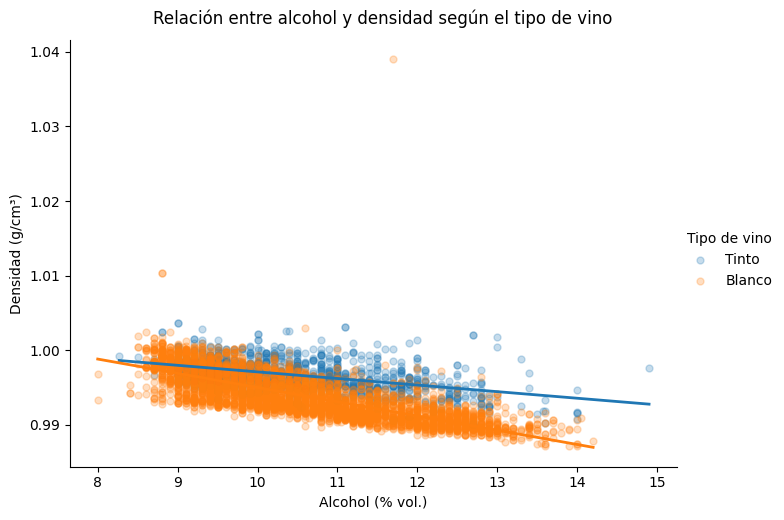

In [ ]:
comparar_relacion_por_tipo(
    df_comparacion,
    "alcohol",
    "density",
    "Relación entre alcohol y densidad según el tipo de vino",
    "Alcohol (% vol.)",
    "Densidad (g/cm³)"
)

En ambos tipos de vino existe una relación negativa entre el alcohol y la densidad: conforme aumenta el contenido de alcohol, la densidad tiende a disminuir. Esta relación es moderada en los tintos, con una correlación de Spearman de −0.46, y fuerte en los blancos, con −0.82.

Los vinos blancos presentan un nivel de alcohol ligeramente mayor, con una mediana de 10.4, frente a 10.2 en los tintos, y una densidad menor, con una mediana de 0.9937, frente a 0.9967 en los tintos.

Esto significa que, en este conjunto de datos, la relación teórica se cumple con mayor claridad en los vinos blancos: los vinos con más alcohol tienden a ser menos densos, debido a que el alcohol tiene menor densidad que el agua. En los tintos la asociación es menos marcada, lo cual sugiere que otras sustancias disueltas, como azúcares, ácidos y compuestos propios del vino, también influyen en su densidad.

### Azúcar residual y densidad según el tipo de vino

Decidimos comparar el azúcar residual y la densidad porque el azúcar que permanece después de la fermentación forma parte de las sustancias disueltas en el vino. Por ello, se espera que los vinos con mayor azúcar residual tiendan a presentar una densidad más alta.

La comparación permitirá comprobar si esta relación aparece en ambos tipos de vino y si los blancos y tintos presentan patrones diferentes. También ayuda a explicar que la densidad no depende únicamente del alcohol.

,Tipo de vino,N,Media de residual sugar,Mediana de residual sugar,Media de density,Mediana de density,Correlación de Spearman
0,Tinto,1328,2.5930,2.2,0.9967,0.9967,0.4313
1,Blanco,4360,6.4046,5.2,0.9940,0.9937,0.7815


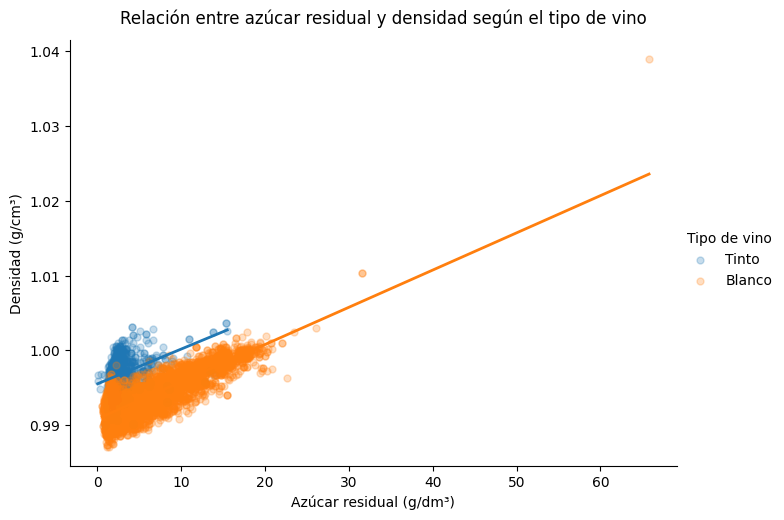

In [ ]:
comparar_relacion_por_tipo(
    df_comparacion,
    "residual sugar",
    "density",
    "Relación entre azúcar residual y densidad según el tipo de vino",
    "Azúcar residual (g/dm³)",
    "Densidad (g/cm³)"
)

En ambos tipos de vino existe una relación positiva: conforme aumenta el azúcar residual, la densidad tiende a incrementarse. La asociación es moderada en los tintos, con una correlación de Spearman de 0.43, y fuerte en los blancos, con 0.78.

Los vinos blancos presentan mayor azúcar residual, con una mediana de 5.2 g/dm³, frente a 2.2 g/dm³ en los tintos. Sin embargo, su densidad central es ligeramente menor: 0.9937 g/cm³ frente a 0.9967 g/cm³. Esto indica que la densidad no depende únicamente del azúcar, sino también del alcohol y de otras sustancias disueltas.

En este conjunto de datos, el aumento del azúcar se relaciona más claramente con una mayor densidad en los vinos blancos. No obstante, la línea de tendencia de este grupo está influida por algunas observaciones extremas, por lo que la correlación de Spearman representa mejor el patrón general que la pendiente visual de la recta.

### Acidez FIja y pH según el tipo de vino

Decidimos comparar la acidez fija y el pH porque ambas variables describen la acidez del vino, pero desde perspectivas diferentes. La acidez fija representa la concentración de los ácidos no volátiles, mientras que el pH indica la intensidad de la acidez presente.

En términos generales, se esperaría que los vinos con mayor acidez fija presenten un pH menor. Sin embargo, esta relación no tiene que ser perfecta, ya que el pH también depende del tipo de ácidos presentes y de la capacidad amortiguadora del vino.

Nos interesa comprobar si esta relación inversa aparece en los datos y si es diferente entre vinos tintos y blancos. Esto permitirá complementar la primera comparación: no solo sabremos qué tipo contiene más ácidos fijos, sino también si esa mayor concentración se refleja en un pH más bajo.

,Tipo de vino,N,Media de fixed acidity,Mediana de fixed acidity,Media de pH,Mediana de pH,Correlación de Spearman
0,Tinto,1333,8.3358,8.0,3.3086,3.31,-0.6995
1,Blanco,4364,6.8451,6.8,3.1862,3.18,-0.4482


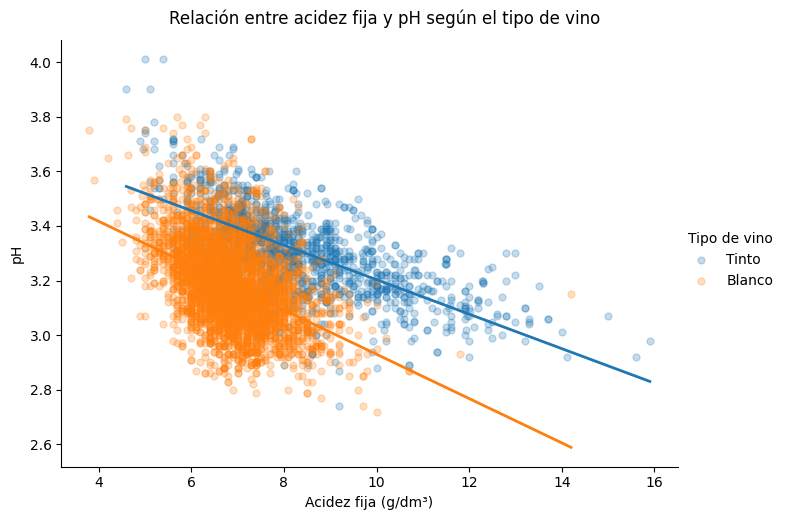

In [ ]:
comparar_relacion_por_tipo(
    df_comparacion,
    "fixed acidity",
    "pH",
    "Relación entre acidez fija y pH según el tipo de vino",
    "Acidez fija (g/dm³)",
    "pH"
)

En ambos tipos de vino existe una relación negativa entre la acidez fija y el pH: conforme aumenta la acidez fija, el pH tiende a disminuir. La asociación es fuerte en los tintos, con una correlación de Spearman de −0.70, y moderada en los blancos, con −0.45.

Los tintos presentan mayor acidez fija, con una mediana de 8.0 g/dm³, frente a 6.8 g/dm³ en los blancos. Sin embargo, también muestran un pH central ligeramente mayor: 3.31 frente a 3.18.

Esto significa que la relación inversa se cumple dentro de cada tipo de vino, especialmente en los tintos, pero el pH no depende únicamente de la cantidad de ácidos fijos. También influyen el tipo de ácidos presentes y otros componentes que regulan la acidez. Por ello, aunque los tintos contienen más acidez fija, los blancos presentan un pH menor y, por tanto, una acidez más intensa según esta escala.

## Inciso 5: Análisis con respecto a la calidad

**Objetivo:** Ver si los vinos mejor calificados tienen patrones distintos en su composición (más alcohol, menos acidez volátil, etc.). Agrupamos la calidad en 3 categorías: **Baja (3-4)**, **Media (5-6)**, **Alta (7-9)**.


In [ ]:
# Creamos grupos de calidad:
# Baja: calidad 3 y 4
# Media: calidad 5 y 6
# Alta: calidad 7, 8 y 9

df_imputado["grupo_calidad"] = pd.cut(
    df_imputado["quality"],
    bins=[2, 4, 6, 9],
    labels=["Baja", "Media", "Alta"],
    include_lowest=True
)

# Calculamos la media de cada variable por grupo de calidad
comparacion_calidad = (
    df_imputado
    .groupby("grupo_calidad", observed=False)[columnas_numericas]
    .mean()
    .round(3)
)

print("Promedio de las variables según la calidad del vino:")
display(comparacion_calidad)

# Calculamos la diferencia entre los vinos de calidad alta y baja
diferencia_calidad = (
    comparacion_calidad.loc["Alta"]
    - comparacion_calidad.loc["Baja"]
).sort_values(ascending=False)

diferencia_calidad = diferencia_calidad.to_frame(
    name="Diferencia Alta - Baja"
)

print("Diferencia entre vinos de calidad alta y baja:")
display(diferencia_calidad.round(3))

Promedio de las variables según la calidad del vino:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
grupo_calidad,,,,,,,,,,,
Baja,7.309,0.452,0.273,4.212,0.061,22.757,104.305,0.995,3.230,0.503,10.177
Media,7.239,0.345,0.316,5.709,0.058,30.962,118.236,0.995,3.214,0.530,10.273
Alta,7.054,0.293,0.334,4.819,0.044,31.128,110.342,0.993,3.227,0.537,11.432


Diferencia entre vinos de calidad alta y baja:


,Diferencia Alta - Baja
free sulfur dioxide,8.371
total sulfur dioxide,6.037
alcohol,1.255
residual sugar,0.607
citric acid,0.061
sulphates,0.034
density,-0.002
pH,-0.003
chlorides,-0.017
volatile acidity,-0.159


Al comparar los promedios por nivel de calidad, observamos que los vinos de calidad alta presentan un mayor contenido de **alcohol**, con un promedio de 11.432 en comparación a 10.177 en los vinos de calidad baja con una diferencia de 1.255.

Por su  parte, la **acidez volátil** disminuye conforme aumenta la calidad, pasando de 0.452 en los vinos de calidad baja a 0.293 en los de calidad alta. También se observa una reducción en los **cloruros** y en la **densidad**, lo cual nos indica que los vinos de mejor calidad tienden a presentar menor acidez volátil, menor concentración de sales y una densidad ligeramente inferior.

Por otro lado, el **ácido cítrico** y los **sulfatos** aumentan ligeramente en los vinos de calidad alta. La **acidez fija** y el **pH** presentan diferencias minimas entre los grupos, por lo que no pareciera ser que haya una distinción de manera importante en la calidad del vino.

El **azúcar residual** y el **dióxido de azufre total** no muestran un comportamiento creciente o decreciente constante, ya que sus valores más altos aparecen en el grupo de calidad media. Por esta razón, no se puede afirmar que una mayor cantidad de estas variables esté directamente relacionada con una mejor calidad.

En general, las variables que muestran las diferencias más claras entre los vinos de calidad baja y alta son el alcohol, la acidez volátil y los cloruros.

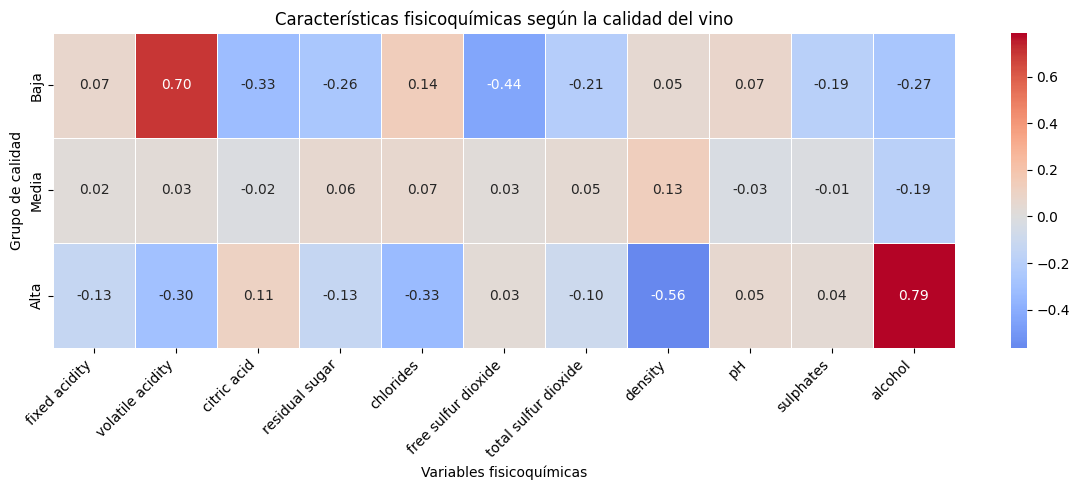

In [ ]:
# Estandarizamos las variables para hacerlas comparables
df_estandarizado = df_imputado.copy()

df_estandarizado[columnas_numericas] = (
    df_estandarizado[columnas_numericas]
    - df_estandarizado[columnas_numericas].mean()
) / df_estandarizado[columnas_numericas].std()

# Calculamos el promedio estandarizado por grupo de calidad
promedios_estandarizados = (
    df_estandarizado
    .groupby("grupo_calidad", observed=False)[columnas_numericas]
    .mean()
)

# Graficamos el mapa de calor
plt.figure(figsize=(12, 5))

sns.heatmap(
    promedios_estandarizados,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Características fisicoquímicas según la calidad del vino")
plt.xlabel("Variables fisicoquímicas")
plt.ylabel("Grupo de calidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El mapa de calor nos confirma los resultados obtenidos mediante los promedios. Los vinos de calidad alta se caracterizan principalmente por un mayor contenido de alcohol y menores niveles de acidez volátil, cloruros y densidad. Por su parte, los vinos de calidad baja presentan una acidez volátil considerablemente superior al promedio y menores niveles de alcohol. Variables como la acidez fija, el pH y los sulfatos muestran diferencias menores entre los grupos, mientras que el azúcar residual y el dióxido de azufre total no presentan un comportamiento constante conforme aumenta la calidad.

---
## Inciso 6: Matriz de correlación

**Objetivo:** Medir qué tan relacionadas están las variables entre sí, y ver cuáles se mueven más juntas.

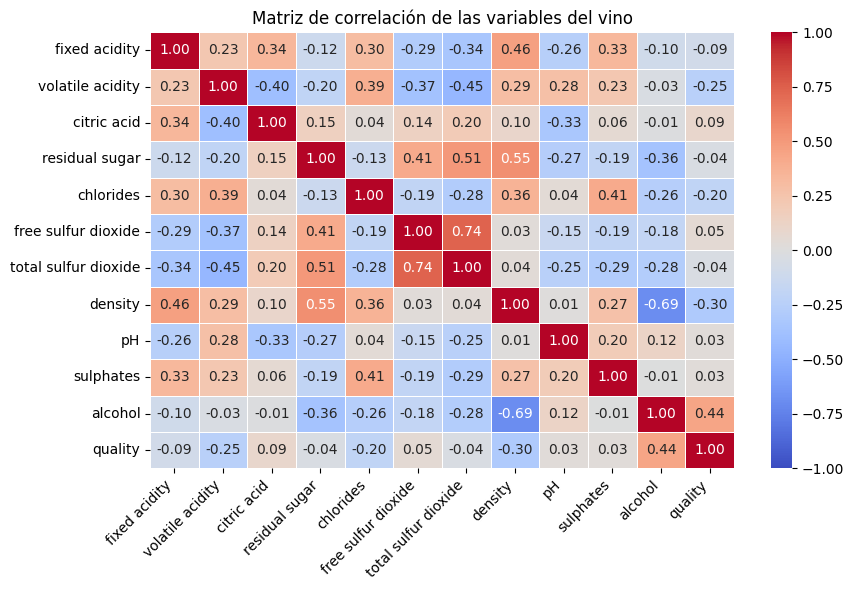

Variables con mayor correlación respecto a la calidad:


,Correlacion con quality
alcohol,0.440
density,-0.300
volatile acidity,-0.248
chlorides,-0.196
citric acid,0.089
fixed acidity,-0.087
free sulfur dioxide,0.054
total sulfur dioxide,-0.037
residual sugar,-0.036
sulphates,0.026


In [ ]:
# Creamos una nueva lista
variables_correlacion = columnas_numericas + ["quality"]

# Calculamos la matriz de correlacion
matriz_correlacion = (
    df_imputado[variables_correlacion]
    .corr()
)

# Graficamos la matriz de correlacion
plt.figure(figsize=(9, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Matriz de correlación de las variables del vino")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlaciones de cada variable con la calidad
correlacion_calidad = (
    matriz_correlacion["quality"]
    .drop("quality")
    .sort_values(key=abs, ascending=False)
)

print("Variables con mayor correlación respecto a la calidad:")
display(
    correlacion_calidad
    .to_frame(name="Correlacion con quality")
    .round(3)
)

Depues de analizar los datos obtenidos vemos que matriz muestra correlaciones coherentes entre las variables.

Notemos que a relación positiva más fuerte se presenta entre el dióxido de azufre libre y el total, lo que tiene sentido ya que el primero forma parte del segundo. También existe una correlación positiva entre el azúcar residual y la densidad, pues una mayor cantidad de azúcar disuelta incrementa la densidad del vino. Por otro lado, la relación negativa más fuerte se observa entre el alcohol y la densidad, debido a que un mayor cantidad de alcohol reduce la densidad.
Por lo tanto, las variables con mayor correlación son el dióxido de azufre libre y total, el alcohol y la densidad, y el azúcar residual y la densidad.